## 📥 STEP 1 — Upload Dataset
Run this cell and click **'Choose Files'** to upload your `shopping_behavior_updated.csv` file from your computer.

> **Download the dataset first from Kaggle:**
> https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


## 📦 STEP 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 STEP 3 — Load the Dataset

In [7]:
# Load dataset (update filename if yours is different)
df = pd.read_csv('shopping_trends_updated.csv')

print('✅ Dataset loaded successfully!')
print(f'📊 Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}')
df.head()

✅ Dataset loaded successfully!
📊 Total Rows: 3900 | Total Columns: 18


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


---
## 🔍 STEP 4 — Explore the Data (EDA)
### 4.1 — Basic Info

In [8]:
print('=== DATASET INFO ===')
df.info()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used    

### 4.2 — Statistical Summary

In [ ]:
print('=== STATISTICAL SUMMARY ===')
df.describe()

### 4.3 — Check Column Names and Unique Values

In [10]:
print('=== COLUMN NAMES ===')
print(df.columns.tolist())

print('\n=== UNIQUE VALUES IN KEY COLUMNS ===')
for col in ['Gender', 'Category', 'Season', 'Payment Method', 'Subscription Status']:
    if col in df.columns:
        print(f'{col}: {df[col].unique()}')

=== COLUMN NAMES ===
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']

=== UNIQUE VALUES IN KEY COLUMNS ===
Gender: ['Male' 'Female']
Category: ['Clothing' 'Footwear' 'Outerwear' 'Accessories']
Season: ['Winter' 'Spring' 'Summer' 'Fall']
Payment Method: ['Venmo' 'Cash' 'Credit Card' 'PayPal' 'Bank Transfer' 'Debit Card']
Subscription Status: ['Yes' 'No']


---
## 🧹 STEP 5 — Data Cleaning

In [9]:
print('=== MISSING VALUES ===')
print(df.isnull().sum())

print(f'\n=== DUPLICATE ROWS ===')
print(f'Duplicates found: {df.duplicated().sum()}')

# Drop missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()

print(f'\n✅ Data cleaned! Final shape: {df.shape}')

=== MISSING VALUES ===
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

=== DUPLICATE ROWS ===
Duplicates found: 0

✅ Data cleaned! Final shape: (3900, 18)


---
## 📊 STEP 6 — Data Visualizations & Analysis

### 📈 Chart 1 — Purchase Amount Distribution
**Business Question:** How much do customers usually spend per transaction?

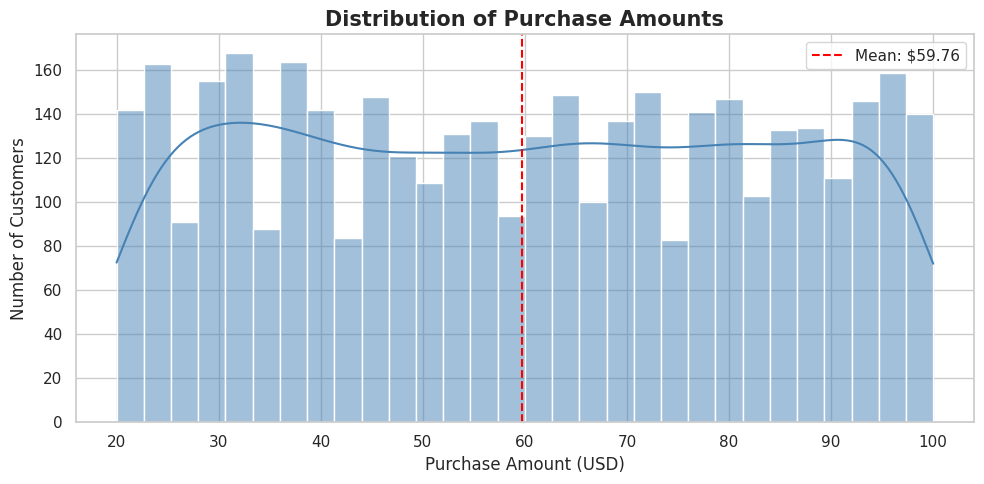

📌 Insight: Average purchase amount is $59.76
   Minimum: $20 | Maximum: $100


In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Purchase Amount (USD)'], bins=30, color='steelblue', kde=True)
plt.title('Distribution of Purchase Amounts', fontsize=15, fontweight='bold')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Number of Customers')
plt.axvline(df['Purchase Amount (USD)'].mean(), color='red', linestyle='--', label=f"Mean: ${df['Purchase Amount (USD)'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('chart1_purchase_distribution.png', dpi=150)
plt.show()

print(f"📌 Insight: Average purchase amount is ${df['Purchase Amount (USD)'].mean():.2f}")
print(f"   Minimum: ${df['Purchase Amount (USD)'].min()} | Maximum: ${df['Purchase Amount (USD)'].max()}")

### 📈 Chart 2 — Purchases by Gender
**Business Question:** Do male or female customers purchase more?

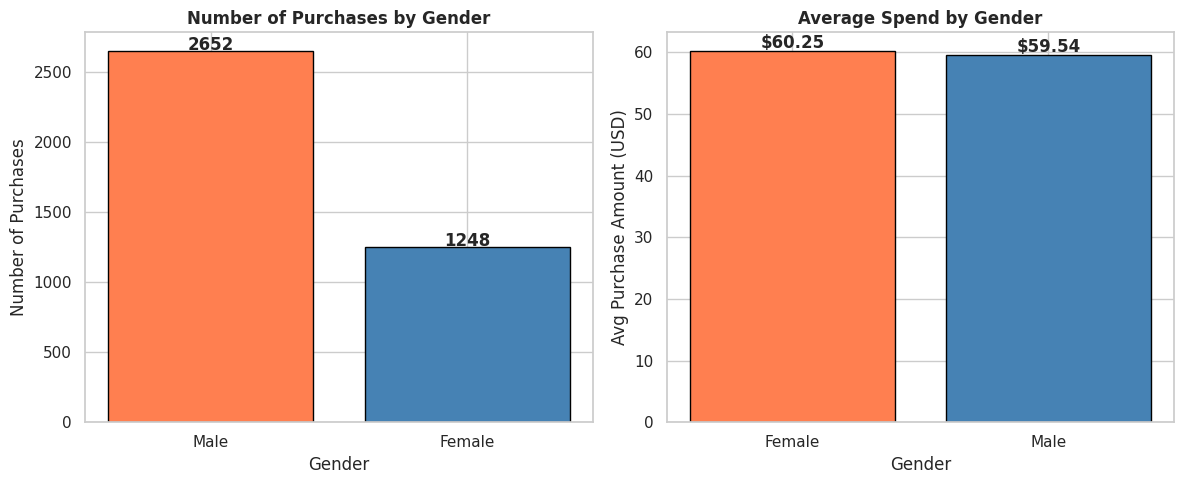

📌 Insight:
   Male: 2652 purchases (68.0%)
   Female: 1248 purchases (32.0%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count of purchases
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['coral', 'steelblue'], edgecolor='black')
axes[0].set_title('Number of Purchases by Gender', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Purchases')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Average spend
gender_avg = df.groupby('Gender')['Purchase Amount (USD)'].mean()
axes[1].bar(gender_avg.index, gender_avg.values, color=['coral', 'steelblue'], edgecolor='black')
axes[1].set_title('Average Spend by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Avg Purchase Amount (USD)')
for i, v in enumerate(gender_avg.values):
    axes[1].text(i, v + 0.5, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_gender_analysis.png', dpi=150)
plt.show()

print('📌 Insight:')
for g, c in gender_counts.items():
    print(f'   {g}: {c} purchases ({c/len(df)*100:.1f}%)')

### 📈 Chart 3 — Most Popular Product Categories
**Business Question:** Which product categories do customers buy the most?

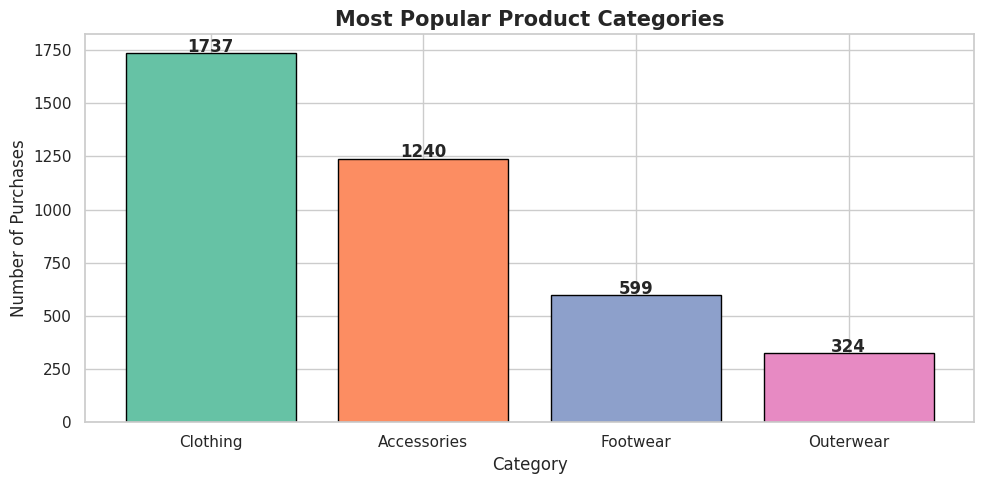

📌 Insight:
   Clothing: 1737 purchases (44.5%)
   Accessories: 1240 purchases (31.8%)
   Footwear: 599 purchases (15.4%)
   Outerwear: 324 purchases (8.3%)


In [13]:
plt.figure(figsize=(10, 5))
category_counts = df['Category'].value_counts()
bars = plt.bar(category_counts.index, category_counts.values,
               color=sns.color_palette('Set2', len(category_counts)), edgecolor='black')
plt.title('Most Popular Product Categories', fontsize=15, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Purchases')
for bar, val in zip(bars, category_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_category_analysis.png', dpi=150)
plt.show()

print('📌 Insight:')
for cat, cnt in category_counts.items():
    print(f'   {cat}: {cnt} purchases ({cnt/len(df)*100:.1f}%)')

### 📈 Chart 4 — Purchase by Age Group
**Business Question:** Which age group spends the most money?

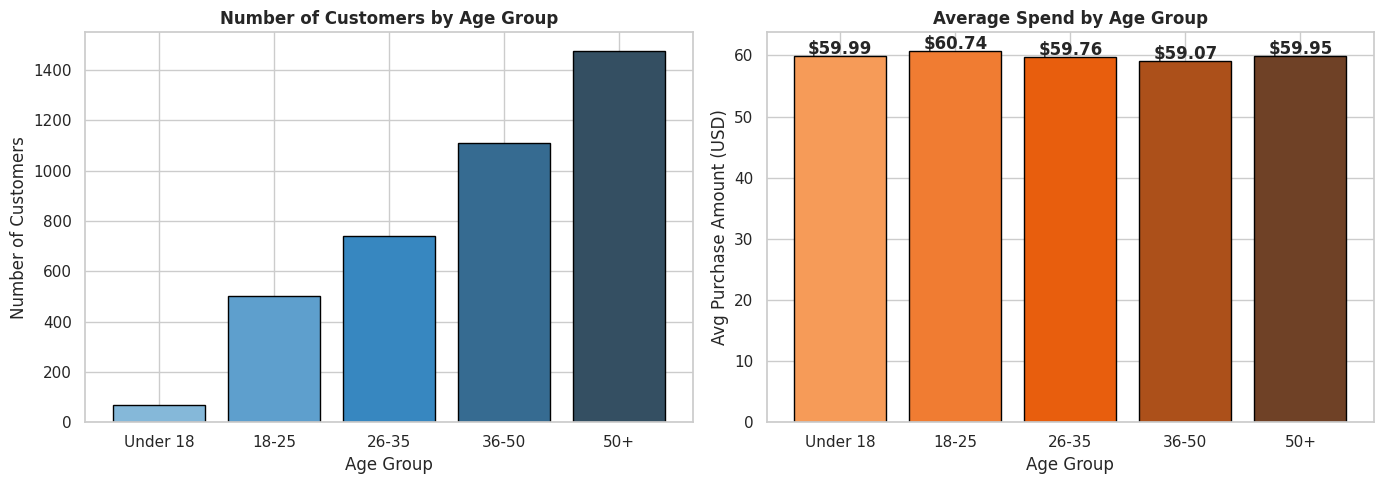

📌 Insight: The 18-25 age group has the highest average spend at $60.74


In [14]:
# Create age groups
bins = [0, 18, 25, 35, 50, 100]
labels = ['Under 18', '18-25', '26-35', '36-50', '50+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count by age group
age_counts = df['Age Group'].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values,
            color=sns.color_palette('Blues_d', len(age_counts)), edgecolor='black')
axes[0].set_title('Number of Customers by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Customers')

# Avg spend by age group
age_avg = df.groupby('Age Group')['Purchase Amount (USD)'].mean().sort_index()
axes[1].bar(age_avg.index, age_avg.values,
            color=sns.color_palette('Oranges_d', len(age_avg)), edgecolor='black')
axes[1].set_title('Average Spend by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Avg Purchase Amount (USD)')
for i, v in enumerate(age_avg.values):
    axes[1].text(i, v + 0.3, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_age_group_analysis.png', dpi=150)
plt.show()

top_age = age_avg.idxmax()
print(f'📌 Insight: The {top_age} age group has the highest average spend at ${age_avg.max():.2f}')

### 📈 Chart 5 — Payment Method Preference
**Business Question:** How do customers prefer to pay?

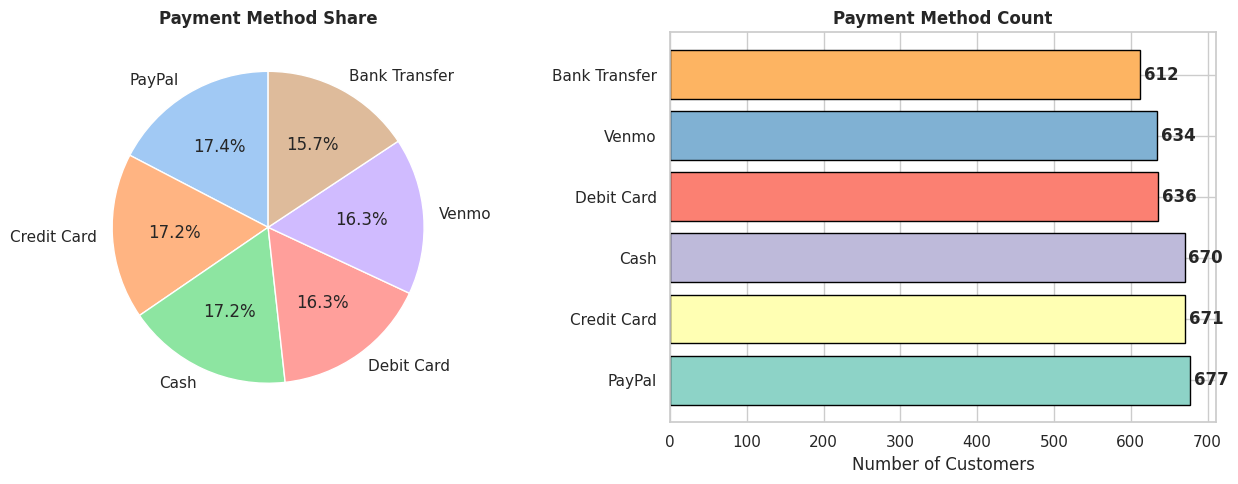

📌 Insight:
   PayPal: 677 customers (17.4%)
   Credit Card: 671 customers (17.2%)
   Cash: 670 customers (17.2%)
   Debit Card: 636 customers (16.3%)
   Venmo: 634 customers (16.3%)
   Bank Transfer: 612 customers (15.7%)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

payment_counts = df['Payment Method'].value_counts()

# Pie chart
axes[0].pie(payment_counts.values, labels=payment_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('pastel', len(payment_counts)))
axes[0].set_title('Payment Method Share', fontweight='bold')

# Bar chart
axes[1].barh(payment_counts.index, payment_counts.values,
             color=sns.color_palette('Set3', len(payment_counts)), edgecolor='black')
axes[1].set_title('Payment Method Count', fontweight='bold')
axes[1].set_xlabel('Number of Customers')
for i, v in enumerate(payment_counts.values):
    axes[1].text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_payment_method.png', dpi=150)
plt.show()

print('📌 Insight:')
for pm, cnt in payment_counts.items():
    print(f'   {pm}: {cnt} customers ({cnt/len(df)*100:.1f}%)')

### 📈 Chart 6 — Seasonal Purchasing Trends
**Business Question:** In which season do customers spend the most?

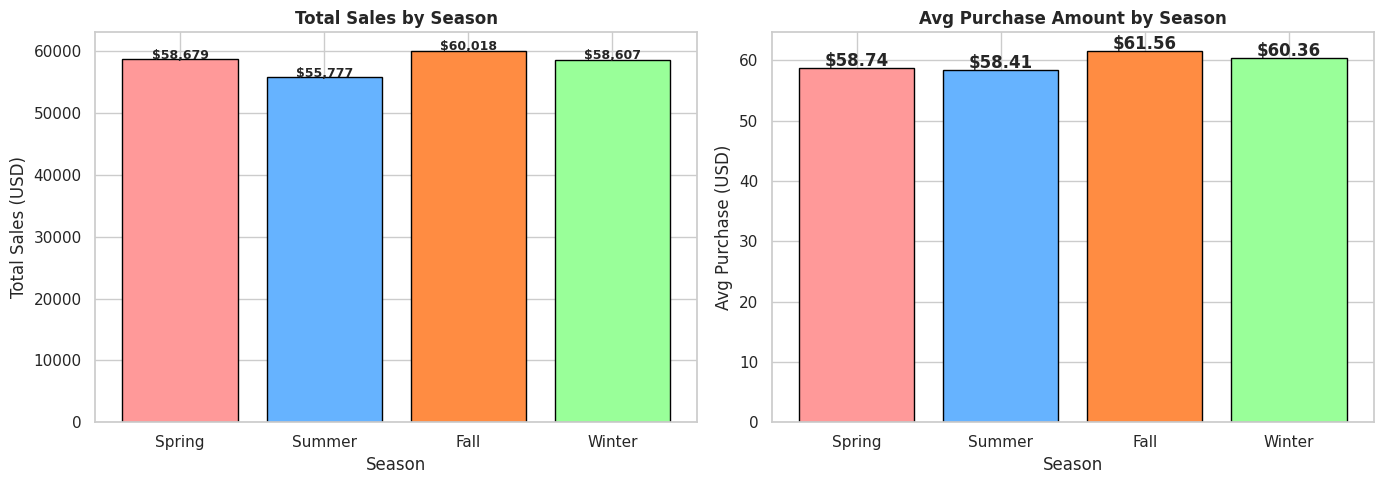

📌 Insight: Fall has the highest total sales at $60,018.00


In [16]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_data = df.groupby('Season')['Purchase Amount (USD)'].agg(['sum', 'mean', 'count'])
season_data.columns = ['Total Sales', 'Avg Purchase', 'Num Customers']

# Reorder seasons
season_data = season_data.reindex([s for s in season_order if s in season_data.index])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#ff9999', '#66b3ff', '#ff8c42', '#99ff99']

axes[0].bar(season_data.index, season_data['Total Sales'], color=colors, edgecolor='black')
axes[0].set_title('Total Sales by Season', fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Total Sales (USD)')
for i, v in enumerate(season_data['Total Sales']):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(season_data.index, season_data['Avg Purchase'], color=colors, edgecolor='black')
axes[1].set_title('Avg Purchase Amount by Season', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Avg Purchase (USD)')
for i, v in enumerate(season_data['Avg Purchase']):
    axes[1].text(i, v + 0.3, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart6_seasonal_trends.png', dpi=150)
plt.show()

top_season = season_data['Total Sales'].idxmax()
print(f'📌 Insight: {top_season} has the highest total sales at ${season_data["Total Sales"].max():,.2f}')

### 📈 Chart 7 — Category vs Average Purchase Amount
**Business Question:** Which category generates the highest revenue per purchase?

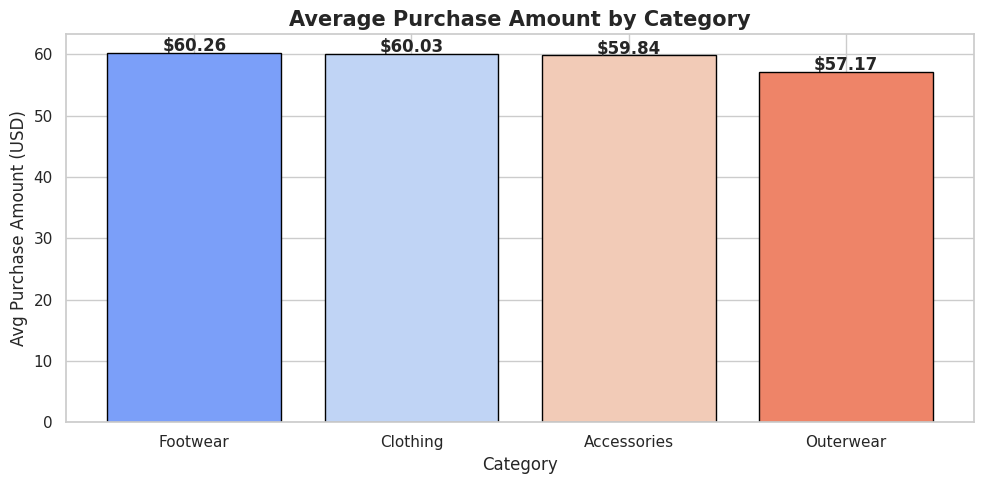

📌 Insight: Footwear has the highest avg purchase at $60.26


In [17]:
plt.figure(figsize=(10, 5))
cat_avg = df.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending=False)
bars = plt.bar(cat_avg.index, cat_avg.values,
               color=sns.color_palette('coolwarm', len(cat_avg)), edgecolor='black')
plt.title('Average Purchase Amount by Category', fontsize=15, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Avg Purchase Amount (USD)')
for bar, val in zip(bars, cat_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'${val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_category_avg_purchase.png', dpi=150)
plt.show()

print(f'📌 Insight: {cat_avg.idxmax()} has the highest avg purchase at ${cat_avg.max():.2f}')

### 📈 Chart 8 — Correlation Heatmap
**Business Question:** Which numerical factors are related to each other?

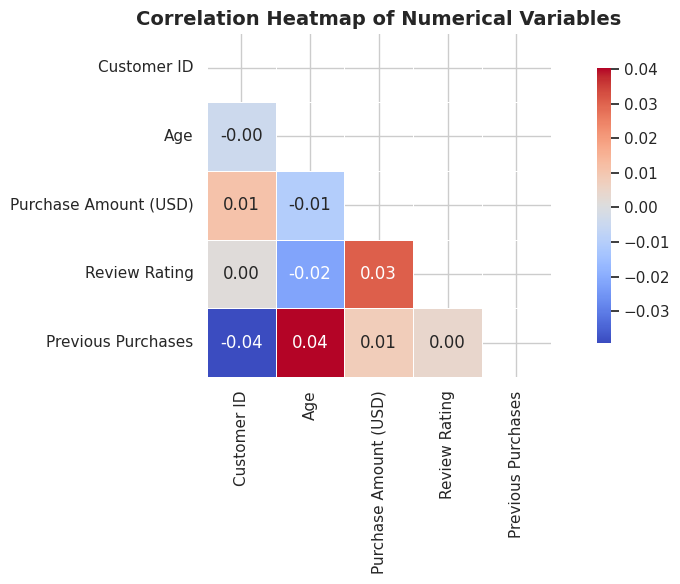

📌 Insight: Values close to 1 or -1 show strong relationships between variables.
   Values close to 0 show little to no relationship.


In [18]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=mask,
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_heatmap.png', dpi=150)
plt.show()

print('📌 Insight: Values close to 1 or -1 show strong relationships between variables.')
print('   Values close to 0 show little to no relationship.')

### 📈 Chart 9 — Subscription Status vs Purchase Amount
**Business Question:** Do subscribed customers spend more than non-subscribed?

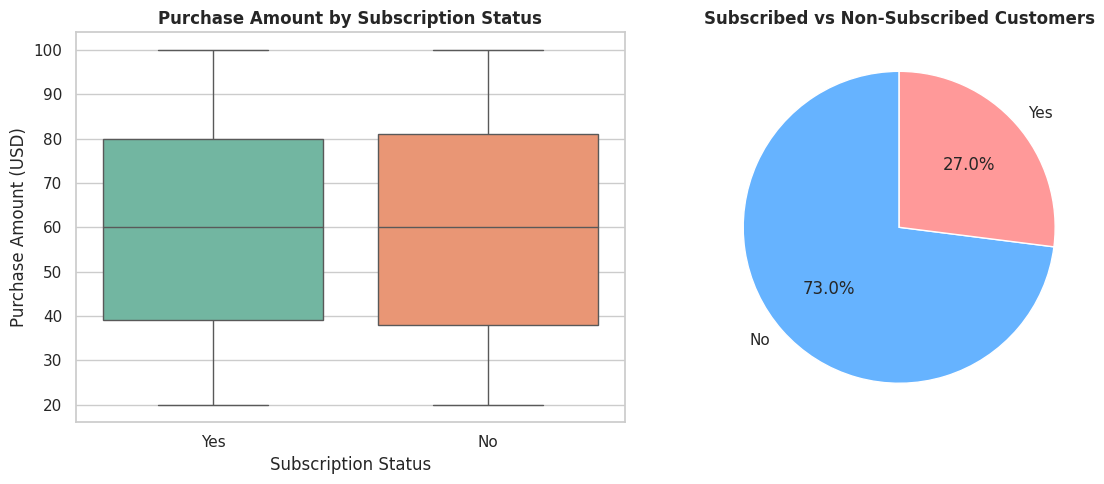

📌 Insight — Avg Purchase Amount by Subscription Status:
   No: $59.87
   Yes: $59.49


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(data=df, x='Subscription Status', y='Purchase Amount (USD)',
            palette='Set2', ax=axes[0])
axes[0].set_title('Purchase Amount by Subscription Status', fontweight='bold')

# Count
sub_counts = df['Subscription Status'].value_counts()
axes[1].pie(sub_counts.values, labels=sub_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#66b3ff', '#ff9999'])
axes[1].set_title('Subscribed vs Non-Subscribed Customers', fontweight='bold')

plt.tight_layout()
plt.savefig('chart9_subscription_analysis.png', dpi=150)
plt.show()

sub_avg = df.groupby('Subscription Status')['Purchase Amount (USD)'].mean()
print('📌 Insight — Avg Purchase Amount by Subscription Status:')
for status, avg in sub_avg.items():
    print(f'   {status}: ${avg:.2f}')

### 📈 Chart 10 — Top 10 Most Purchased Items
**Business Question:** What are the most popular individual products?

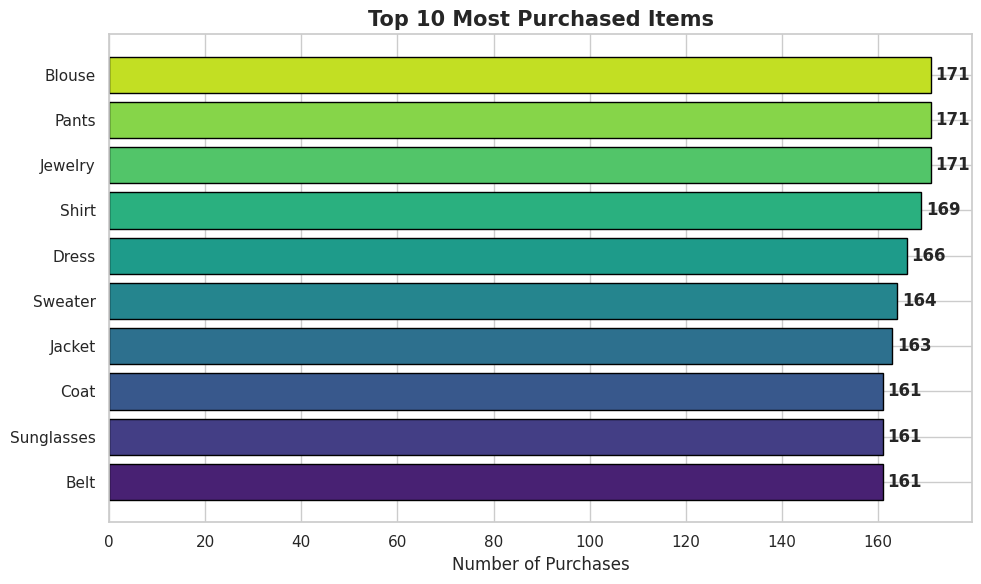

📌 Insight — Top 5 Most Purchased Items:
   Blouse: 171 purchases
   Pants: 171 purchases
   Jewelry: 171 purchases
   Shirt: 169 purchases
   Dress: 166 purchases


In [20]:
plt.figure(figsize=(10, 6))
top_items = df['Item Purchased'].value_counts().head(10)
bars = plt.barh(top_items.index[::-1], top_items.values[::-1],
                color=sns.color_palette('viridis', 10), edgecolor='black')
plt.title('Top 10 Most Purchased Items', fontsize=15, fontweight='bold')
plt.xlabel('Number of Purchases')
for bar, val in zip(bars, top_items.values[::-1]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart10_top_items.png', dpi=150)
plt.show()

print('📌 Insight — Top 5 Most Purchased Items:')
for item, cnt in top_items.head(5).items():
    print(f'   {item}: {cnt} purchases')

---
## 💡 STEP 7 — Key Findings & Business Insights

In [21]:
print('=' * 60)
print('       📊 CUSTOMER BEHAVIOUR ANALYSIS — SUMMARY')
print('=' * 60)

print(f"""
📌 FINDING 1 — Purchase Amount
   Average spend per transaction: ${df['Purchase Amount (USD)'].mean():.2f}
   Most customers spend between ${df['Purchase Amount (USD)'].quantile(0.25):.0f} and ${df['Purchase Amount (USD)'].quantile(0.75):.0f}

📌 FINDING 2 — Gender
   Dominant customer gender: {df['Gender'].value_counts().idxmax()}
   ({df['Gender'].value_counts().max()} purchases = {df['Gender'].value_counts().max()/len(df)*100:.1f}% of total)

📌 FINDING 3 — Top Category
   Most popular product category: {df['Category'].value_counts().idxmax()}
   ({df['Category'].value_counts().max()} purchases)

📌 FINDING 4 — Payment Method
   Most preferred payment method: {df['Payment Method'].value_counts().idxmax()}
   ({df['Payment Method'].value_counts().max()} customers = {df['Payment Method'].value_counts().max()/len(df)*100:.1f}%)

📌 FINDING 5 — Top Item
   Most purchased individual item: {df['Item Purchased'].value_counts().idxmax()}
""")

print('=' * 60)
print('       💼 BUSINESS RECOMMENDATIONS')
print('=' * 60)
print("""
✅ RECOMMENDATION 1:
   Focus marketing budgets on the top product category
   as it drives the most purchases.

✅ RECOMMENDATION 2:
   Ensure the most preferred payment method is seamless
   and offer discounts for using it to retain customers.

✅ RECOMMENDATION 3:
   Create loyalty programs targeting subscribed customers
   as they tend to be more engaged with the platform.

✅ RECOMMENDATION 4:
   Run seasonal promotions during peak seasons to
   maximise revenue when customers are most likely to buy.

✅ RECOMMENDATION 5:
   Stock up inventory for the top 10 most purchased items
   to avoid stockouts during peak demand periods.
""")

       📊 CUSTOMER BEHAVIOUR ANALYSIS — SUMMARY

📌 FINDING 1 — Purchase Amount
   Average spend per transaction: $59.76
   Most customers spend between $39 and $81

📌 FINDING 2 — Gender
   Dominant customer gender: Male
   (2652 purchases = 68.0% of total)

📌 FINDING 3 — Top Category
   Most popular product category: Clothing
   (1737 purchases)

📌 FINDING 4 — Payment Method
   Most preferred payment method: PayPal
   (677 customers = 17.4%)

📌 FINDING 5 — Top Item
   Most purchased individual item: Blouse

       💼 BUSINESS RECOMMENDATIONS

✅ RECOMMENDATION 1:
   Focus marketing budgets on the top product category
   as it drives the most purchases.

✅ RECOMMENDATION 2:
   Ensure the most preferred payment method is seamless
   and offer discounts for using it to retain customers.

✅ RECOMMENDATION 3:
   Create loyalty programs targeting subscribed customers
   as they tend to be more engaged with the platform.

✅ RECOMMENDATION 4:
   Run seasonal promotions during peak seasons to
   m

---
## 📥 STEP 8 — Download All Charts
Run this to download all your saved charts at once to your computer.

In [22]:
import os
from google.colab import files

charts = [
    'chart1_purchase_distribution.png',
    'chart2_gender_analysis.png',
    'chart3_category_analysis.png',
    'chart4_age_group_analysis.png',
    'chart5_payment_method.png',
    'chart6_seasonal_trends.png',
    'chart7_category_avg_purchase.png',
    'chart8_heatmap.png',
    'chart9_subscription_analysis.png',
    'chart10_top_items.png'
]

for chart in charts:
    if os.path.exists(chart):
        files.download(chart)
        print(f'✅ Downloaded: {chart}')
    else:
        print(f'⚠️ Not found (run the chart cell first): {chart}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: chart1_purchase_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: chart9_subscription_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: chart10_top_items.png
